# Identitas Mahasiswa

Nama: Muhammad Sir Kafi El Migwar

NIM: 250401020081

Kelas: IF405

=== Shape Dataset ===
(244, 7)

=== Tipe Data ===
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

=== 5 Data Teratas ===
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

=== Statistik Deskriptif ===
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


/tmp/ipykernel_1042/838787868.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_day = df.groupby('day')['total_bill'].mean()


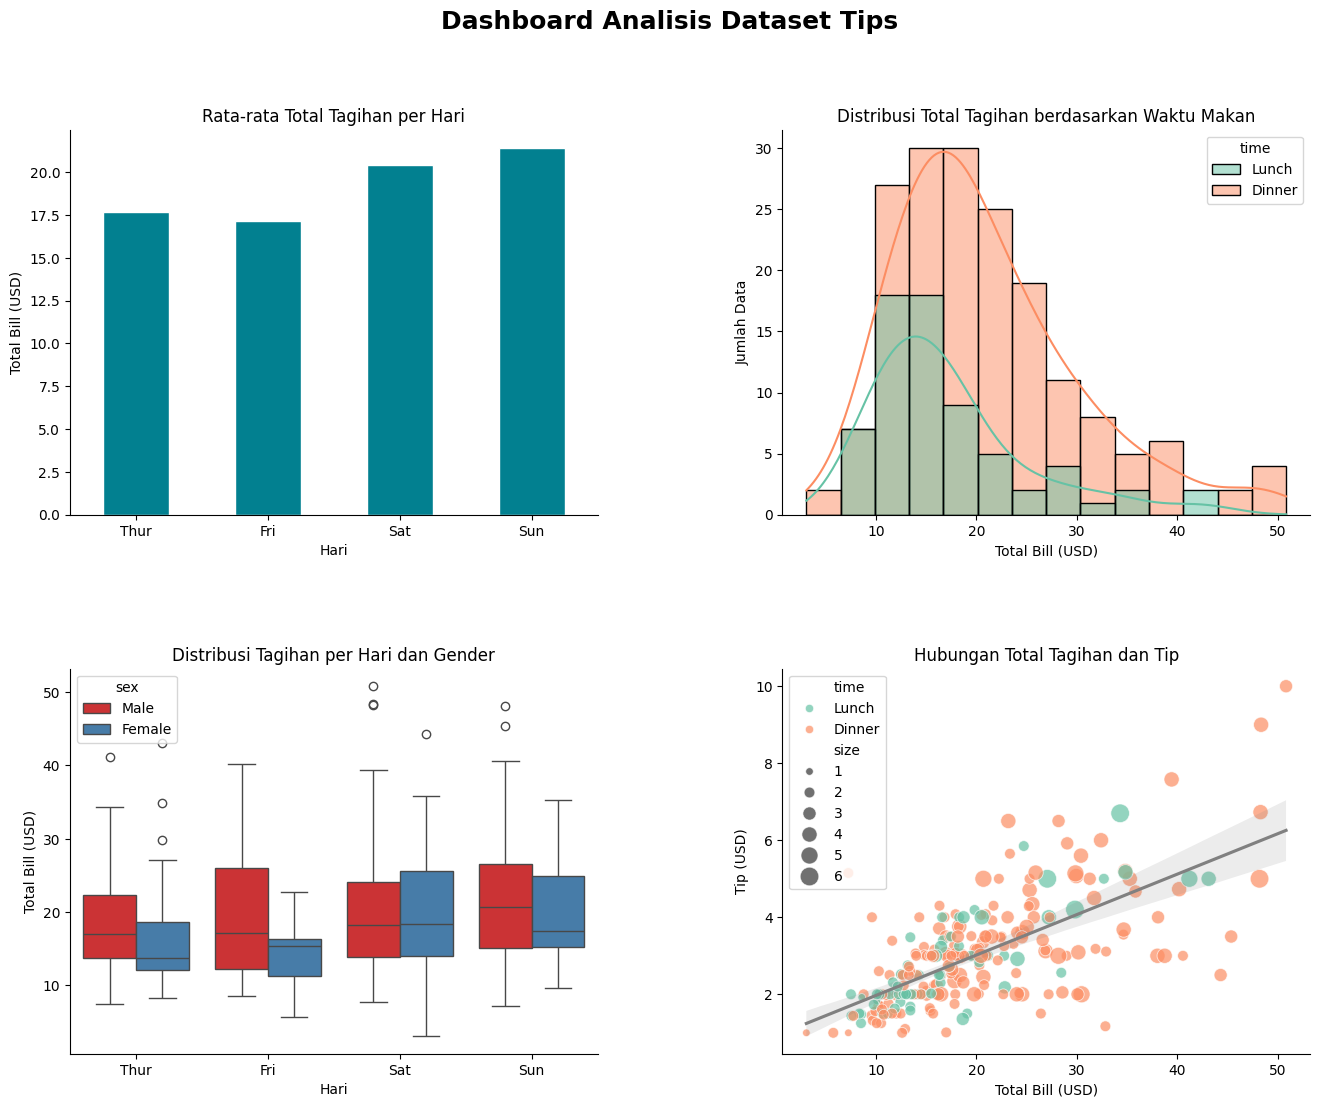

Dashboard berhasil disimpan sebagai dashboard_tips.png


In [6]:
# =====================================================
# PERTEMUAN 5 - DASHBOARD VISUALISASI STATIS
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# =====================================================
# 1. LOAD & INSPECT DATASET
# =====================================================

df = sns.load_dataset('tips')

print("=== Shape Dataset ===")
print(df.shape)

print("\n=== Tipe Data ===")
print(df.dtypes)

print("\n=== 5 Data Teratas ===")
print(df.head())

print("\n=== Statistik Deskriptif ===")
print(df.describe().round(2))


# =====================================================
# 2. SETUP FIGURE LAYOUT
# =====================================================

fig = plt.figure(figsize=(16, 12))

fig.suptitle(
    'Dashboard Analisis Dataset Tips',
    fontsize=18,
    fontweight='bold',
    y=0.98
)

gs = gridspec.GridSpec(
    2, 2,
    figure=fig,
    hspace=0.4,
    wspace=0.35
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])


# =====================================================
# 3. GRAFIK 1 - BAR CHART
# =====================================================

avg_by_day = df.groupby('day')['total_bill'].mean()

avg_by_day.plot(
    kind='bar',
    ax=ax1,
    color='#028090',
    edgecolor='white'
)

ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari')
ax1.set_ylabel('Total Bill (USD)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top', 'right']].set_visible(False)


# =====================================================
# 4. GRAFIK 2 - HISTOGRAM + KDE
# =====================================================

sns.histplot(
    data=df,
    x='total_bill',
    hue='time',
    kde=True,
    palette='Set2',
    ax=ax2
)

ax2.set_title('Distribusi Total Tagihan berdasarkan Waktu Makan')
ax2.set_xlabel('Total Bill (USD)')
ax2.set_ylabel('Jumlah Data')
ax2.spines[['top', 'right']].set_visible(False)


# =====================================================
# 5. GRAFIK 3 - BOXPLOT
# =====================================================

sns.boxplot(
    data=df,
    x='day',
    y='total_bill',
    hue='sex',
    palette='Set1',
    ax=ax3
)

ax3.set_title('Distribusi Tagihan per Hari dan Gender')
ax3.set_xlabel('Hari')
ax3.set_ylabel('Total Bill (USD)')
ax3.spines[['top', 'right']].set_visible(False)


# =====================================================
# 6. GRAFIK 4 - SCATTER PLOT
# =====================================================

sns.scatterplot(
    data=df,
    x='total_bill',
    y='tip',
    hue='time',
    size='size',
    sizes=(30, 180),
    palette='Set2',
    alpha=0.7,
    ax=ax4
)

sns.regplot(
    data=df,
    x='total_bill',
    y='tip',
    scatter=False,
    color='gray',
    ax=ax4
)

ax4.set_title('Hubungan Total Tagihan dan Tip')
ax4.set_xlabel('Total Bill (USD)')
ax4.set_ylabel('Tip (USD)')
ax4.spines[['top', 'right']].set_visible(False)


# =====================================================
# 7. EXPORT DASHBOARD
# =====================================================

plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()

print("Dashboard berhasil disimpan sebagai dashboard_tips.png")


## Interpretasi Dashboard Dataset Tips

Dashboard ini menggunakan dataset tips yang berisi informasi total tagihan, tip, hari, waktu makan, jenis kelamin pelanggan, dan jumlah tamu.

### Grafik 1: Rata-rata Total Tagihan per Hari
Grafik bar menunjukkan rata-rata total tagihan berdasarkan hari. Dari grafik ini dapat dilihat hari mana yang memiliki rata-rata tagihan lebih tinggi dibanding hari lainnya. Informasi ini berguna untuk melihat pola pengeluaran pelanggan berdasarkan hari kunjungan.

### Grafik 2: Distribusi Total Tagihan
Histogram menunjukkan persebaran nilai total tagihan pelanggan. Sebagian besar tagihan berada pada rentang rendah hingga menengah, sedangkan hanya sedikit pelanggan yang memiliki tagihan sangat tinggi. Pembagian berdasarkan waktu makan membantu membandingkan pola tagihan antara lunch dan dinner.

### Grafik 3: Boxplot Total Tagihan
Boxplot digunakan untuk melihat sebaran total tagihan berdasarkan hari dan gender. Grafik ini membantu mengidentifikasi median, variasi data, serta potensi outlier. Dengan boxplot, kita dapat melihat apakah ada kelompok tertentu yang memiliki tagihan lebih tinggi atau lebih menyebar.

### Grafik 4: Hubungan Total Tagihan dan Tip
Scatter plot menunjukkan hubungan antara total tagihan dan jumlah tip. Secara umum, semakin besar total tagihan, maka tip yang diberikan juga cenderung meningkat. Garis regresi membantu menunjukkan adanya hubungan positif antara kedua variabel tersebut.

### Kesimpulan
Berdasarkan dashboard, dataset tips menunjukkan pola bahwa total tagihan memiliki hubungan positif dengan jumlah tip. Selain itu, hari dan waktu makan juga dapat memengaruhi pola total tagihan pelanggan. Dashboard ini membantu memahami data secara visual dan lebih mudah dibanding hanya melihat tabel angka.

## Kesimpulan Pembelajaran Visualisasi Data

Dari praktikum visualisasi data menggunakan dataset penguin, saya memperoleh pemahaman yang lebih baik mengenai bagaimana data dapat disajikan secara visual untuk memudahkan proses analisis dan pengambilan insight.

Beberapa hal yang saya pelajari antara lain:

- Pentingnya melakukan visualisasi jumlah data pada setiap kategori untuk mengetahui keseimbangan distribusi data dan mendeteksi kemungkinan adanya ketimpangan jumlah sampel antar kelompok.
- Penggunaan histogram dan kurva KDE membantu saya memahami pola distribusi suatu variabel serta melihat apakah terdapat perbedaan karakteristik yang cukup jelas antar spesies penguin.
- Melalui boxplot, saya dapat membandingkan sebaran data antar kelompok sekaligus mengidentifikasi perbedaan ukuran, nilai tengah, dan kemungkinan adanya outlier pada masing-masing kategori.
- Scatter plot memberikan gambaran yang lebih jelas mengenai hubungan antara dua variabel numerik, sehingga saya dapat melihat adanya kecenderungan hubungan positif antara panjang sirip dan berat badan penguin.
- Saya juga memahami bahwa pemilihan jenis grafik yang tepat sangat berpengaruh terhadap informasi yang dapat diperoleh dari data.

Secara keseluruhan, praktikum ini membantu saya memahami bahwa visualisasi data bukan hanya berfungsi untuk mempercantik penyajian informasi, tetapi juga menjadi alat analisis yang efektif untuk menemukan pola, membandingkan kelompok data, serta memahami hubungan antar variabel dengan lebih mudah dan intuitif.